# 计算机图形学笔记

20251114

## 第一章 绪论

### 1. 图像学和图形学的区别

### 2. 走样的原因
  
  用离散量表示连续量引起的失真.
### 3. 反走样的概念
  
  减少或消除因走样造成的阶梯形或闪烁的效果的方法称为反走样.反走样技术有:

  1. 前滤波:以较高的分辨率显示对象
  2. 后滤波:加权区域取样

### 4. 直线的扫描转换算法

对直线进行光栅化时,需要在显示器有限个象素中,确定最佳逼近该支线的一组象素,并且按照扫描线顺序,对这些象素进行写操作.这个过程称为显示器绘制直线或直线的扫描转换.

直线的扫描转换算法有:

- DDA算法
- 中点线算法
- Bresenham算法
  
#### 4.1 DDA算法

考虑到增量计算较快的原因，所以没有直接使用 y = kx+b的方法直接计算每个点的横纵坐标。而是使用 y(i) = y(i-1)+k △x  当△x  = 1的时候  y(i) = y(i-1)+k,这样只需要加法运算就可以求出每次的y值。
#### 4.2 Bresenham算法
  
  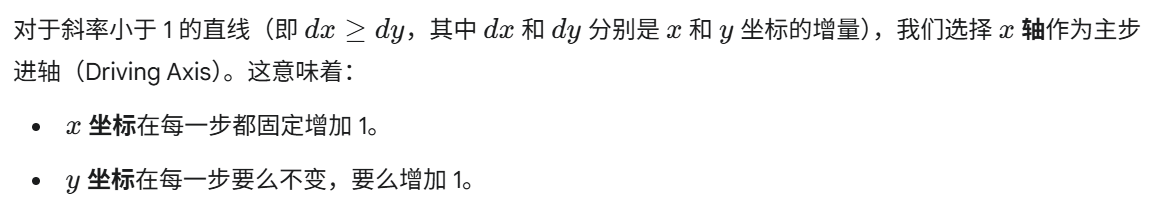

  以此种情况(即dx>dy)为例,每一步x坐标递增之后,y坐标要么不变(水平向右移动),要么以相同幅度递增(对角线方向移动).选择的规则如下:

  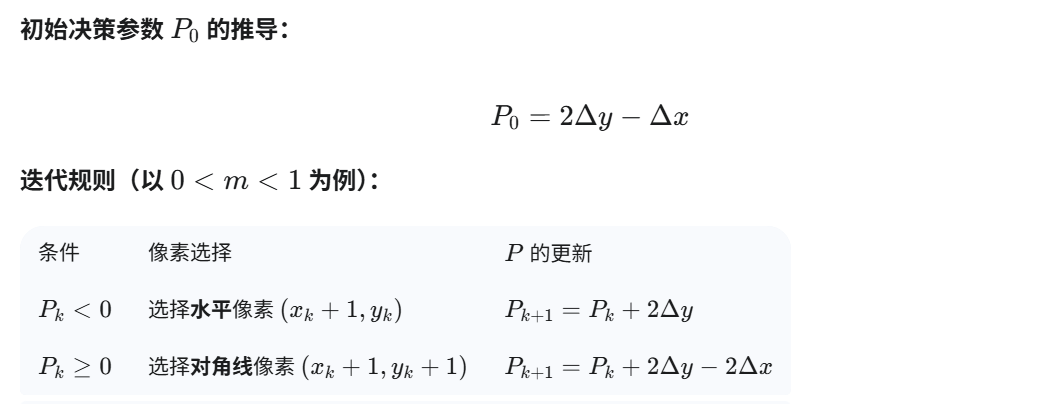

  **注:为了方便计算,可以提前算出两个方向(向右或向右上的)增量.**

  

## 第二章 颜色模型

### 1. 设备无关与设备相关
   - 设备无关的颜色模型:基于人眼对色彩感知的度量建立的数学模型,主要用于计算和测量.
   - 设备相关的颜色模型:以RGB模型为例,一组确定的RGB数值在一个液晶屏上显示,最终会作用到三色LED的电压上.这样一组值在不同设备上解释时,得到的颜色可能不同.
  
### 2. 设备相关与无关的模型例子
  在设备相关,不相关的颜色模型间互相转换,一般是以RGB和CIEXYZ作为桥梁进行的.
  
  - 相关:RGB,CMY,CMYK,HSV
  - 不相关: CIEXYZ

### 3. RGB模型和CMY模型之间的比较

| 比较维度 | RGB (Red, Green, Blue) | CMY (Cyan, Magenta, Yellow) |
| :--- | :--- | :--- |
| **物理原理** | 加色法 (Additive Color) | 减色法 (Subtractive Color) |
| **媒介本质** | 光 (发光体) | 颜料 / 油墨 (吸光物体) |
| **基础底色** | 黑色 (无光) | 白色 (全反射，如白纸) |
| **混合方向** | 颜色越加越亮 | 颜色越加越暗 |
| **最大混合** | R + G + B = 白色 | C + M + Y = 黑色 (理论值) |
| **主要应用** | 显示器、投影仪、相机、手机屏幕 | 打印机、胶印印刷、绘画 |印印刷、绘画、印刷、绘画

## 第三章 物体表示(1)-多边形表示:OBJ,BRep和半边数据结构

### 1.坐标系区别

- 世界坐标系: **场景参照坐标系,一个场景只有一个世界坐标系.** 是用于定义物体在场景中的位置.是一个大范围的参考,用来确定所有物体如何放置在这个虚拟世界中.

- 建模坐标系: **描述单个物体的形状,尺寸所采用的坐标系.** 是针对单个物体的.每个物体都是在它子集的坐标系中被创建和编辑的,就像是每件家具有自己的小平面图.这有助于设计者单独操作和调整每个模型,而不必担心其它模型或整个世界的坐标.

### 2.多边形表示方法:OBJ格式

保存: 1.几何信息.2.纹理信息.3.光线信息.

- 多边形表示的优点:
  + 表示简单.
  + 可以表示具有任意拓扑的物体.
  + 可以表示具有丰富细节的物体.
  + 大部分图形硬件支持多边形物体的加速绘制.
 
- 多边形表示的不足:
  + 逼近表示,难以满足交互时放大需求.
  + 难以用传统方法编辑物体外形.
  + 缺乏解析表达式,几何属性计算困难.
  + 在表示复杂拓扑和具有丰富细节的物体时,数据量庞大,建模/编辑/绘制/存储的负担重.

### 3.BREP表示

实体的边界通常由面的并集来表示;每个面又由他所在的曲面的定义加上其边界来表示,面的边界是边的并集;而边又是由点来表示的.

**BRep是什么?**

A:网格表示数据结构.

**BRep表示的两种类型**

A:1.拓扑信息(即网格之间的关系). 2.几何信息(网格坐标在哪里,大小是多少).

### 4.半边数据结构

- 每条边被记录为两条半边,记录每条半边:
  + 起始顶点的指针.
  + 邻接面的指针.(如果为边界,填充null)
  + (逆时针方向的)下一条半边.
  + 相邻的半边.
  + 前一条半边(可选).
  
- 面:
  边界上的一条半边.

- 顶点:
  + 坐标值.
  + 指向以此为起始端点的半边.

~~~C
struct HE_edge{
    HE_vert* vert; //起始顶点的指针
    HE_edge* pair; //相邻的半边:twin
    HE_face* face; //邻接面的指针
    HE_edge* next; //逆时针方向下一条半边
};
~~~

## 第三章 物体表示(2)参数曲面

### 1.参数表示的优点

- 参数表示是显示的
  - 对每一个参数值,可以直接计算曲面上的对应点.
  - 参数表示的物体可以很方便的转化为多边形逼近表示.
- 曲面上的几何量计算简便
- 特殊形式的参数表示的外形控制十分直观:
  - Bezier,B-样条,NURBS(非均匀有理B-样条)曲线/曲面.
 
### 2.Bezier曲线




## 第四章 Pipeline

### 1. Rendering Pipeline(渲染管道)

- **考点:掌握图形渲染通道的各部分和作用.**

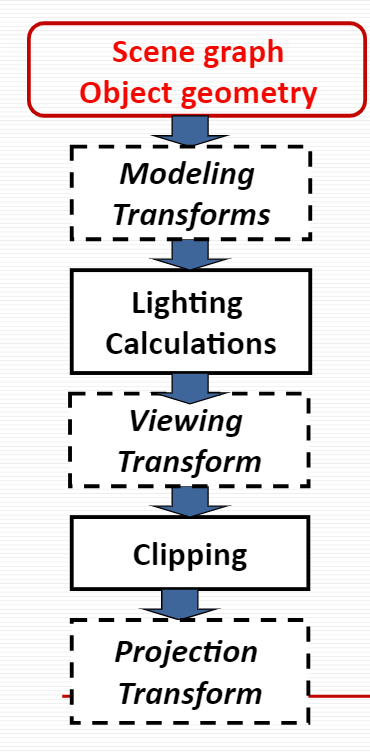

#### Modeling Transforms建模变换
    在建立或编辑三位模型时使用的.这些变换决定了模型的位置,旋转和缩放.可以理解为在虚拟世界中放置和调整模型的过程.

#### Lightning Calculations光照计算
    对场景中的所有几何图元进行照明处理,以模拟现实世界中的光照效果.过程中需要考虑以下几个光照参数:

  + 光源发射(Light source emission):涉及到光源的颜色和强度.包括如何发射光线等.例如点光源,聚光灯或环境光.
  + 表面反射率(Surface reflectance):每种材料不同的发射特性.决定了光线击中表面时反射的量,以及光线反射的方式,例如漫反射或镜面反射.
  + 大气衰减(Atmosphere attenuation):光线在通过介质时的强度减弱程度.
  + 相机响应(Camera response):模拟真实相机对光线的响应,比如光线如何被相机感光元件捕获并转换成图像.
 
    在光照计算过程中通常区分直接照明和全局照明.此处省略.

#### Viewing Transform视图变换
    视图变换的结果是:3D场景转换到视窗/相机坐标系.
    
    这样使得渲染出得图像符合从相机这一特定视角看到的场景.
    
#### Clipping裁剪

    结果:移除视图之外的几何体.

    这样做的好处是提高渲染效率,不必处理那些最终不会出现在最终图像上的数据.

    裁剪通常发生在将三维场景转换到二维图像之前的某个点,确保那些只有能被用户看到的物体才会进入下一步渲染流程.

#### Projection Transform投影转换

    结果:将裁剪后顶点的三维坐标转换为二维屏幕坐标.

    将三维场景的物体映射到二维屏幕上.主要的两种投影方式:

+ 透视投影:这种方式会模拟人眼观察现实世界的效果,远处的物体看起来会更小.
+ 正交投影:这种方式中,所有物体无论远近都保持相同的大小,通常用于工程图纸和建筑设计,因为它可以准确的保持物体的比例和角度.

#### Rasterize光栅化

    在渲染管线中,光栅化Rasterize负责将投影得到的2D图像转换为实际的象素(或点阵图).并确定那些像素将被渲染以及如何渲染.

+ 转换屏幕坐标到像素颜色:这意味着确定由三维物体边缘定义的线条或曲面在屏幕上应该覆盖哪些像素点,并为这些像素点着色.


## 第五章:变换

### 1. 齐次坐标系及其作用

    基本思想是:把一个n维空间的几何问题转换到n+1维空间.从形式上就是用一个n+1维向量表示一个n维空间中的点(向量).

比如:一个二维空间中的点$A(x,y)$的齐次坐标表示为$$(x\ast h,y\ast h,h),\forall h \neq 0.$$

齐次坐标表示不是唯一的.当$h=1$时,称为规格化齐次坐标.

**齐次坐标的作用**:可改写平移变换,缩放变换以及旋转变换为**统一的乘积形式**.

### 2. 二维平移,旋转,缩放矩阵

#### 平移变换

$$
\begin{bmatrix}
x' \\
y' \\
1
\end{bmatrix}
\\=\\
\begin{bmatrix}
1 & 0 & t_x \\ 
0 & 1 & t_y \\
0 & 0 & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
x \\
y \\
1
\end{bmatrix}
$$

$$ P'=T(t_x,t_y)\cdot P$$

**注:连续平移Translations是可加的**!即:

$$T(t_x2,t_y2) \cdot T(t_x1,t_y1) = T(t_x2 + t_x1 , t_y2+t_y1)$$

拓展到三维空间(四维)矩阵情况类似.

#### 旋转变换(坐标原点为旋转中心)

$$
\begin{bmatrix}
x' \\
y' \\
1 
\end{bmatrix}
\\=\\
\begin{bmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta & \cos\theta & 0 \\
0 & 0 & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
x \\
y \\
1 \\
\end{bmatrix}
$$

**注:连续旋转可加**!即:

$$P' = R(\theta_1 + \theta_2) \cdot P$$

拓展到三维空间后,形式根据绕x,y,z轴有所不同.

绕z轴旋转(形式跟2维基本相同):
$$
R_z(\theta) = 
\begin{bmatrix}
\cos\theta & -\sin\theta & 0 & 0\\
\sin\theta & \cos\theta & 0 & 0\\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1\\
\end{bmatrix}
$$

绕x轴旋转:
$$
R_x(\theta) = 
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & \cos\theta & -\sin\theta & 0\\
0 & \sin\theta & \cos\theta & 0 \\
0 & 0 & 0 & 1\\
\end{bmatrix}
$$

绕y轴旋转:
$$
R_y(\theta) = 
\begin{bmatrix}
\cos\theta & 0 & \sin\theta & 0\\
0 & 1 & 0 & 0\\
-\sin\theta & 0 & \cos\theta & 0 \\
0 & 0 & 0 & 1\\
\end{bmatrix}
$$

#### 缩放变换

$$
\begin{bmatrix}
x' \\
y' \\
1 
\end{bmatrix}
\\=\\
\begin{bmatrix}
S_x & 0 & 0 \\
0 & S_y & 0 \\
0 & 0 & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
x \\
y \\
1 \\
\end{bmatrix}
$$

**注:连续缩放式相乘的**!不是叠加,即:

$$S(S_x2,S_y2) \cdot S(S_x1,S_y1) = S(S_x1 \cdot S_x2 , S_y1 \cdot S_y2)$$

拓展到三维空间类似.

**<mark>注意:因为对坐标变化时,原坐标向量在最右边.所以越先做的变换应该越靠右!!!</mark>**

### 3.模型变换,取景变换,投影变换,设备变换,视窗变换的作用

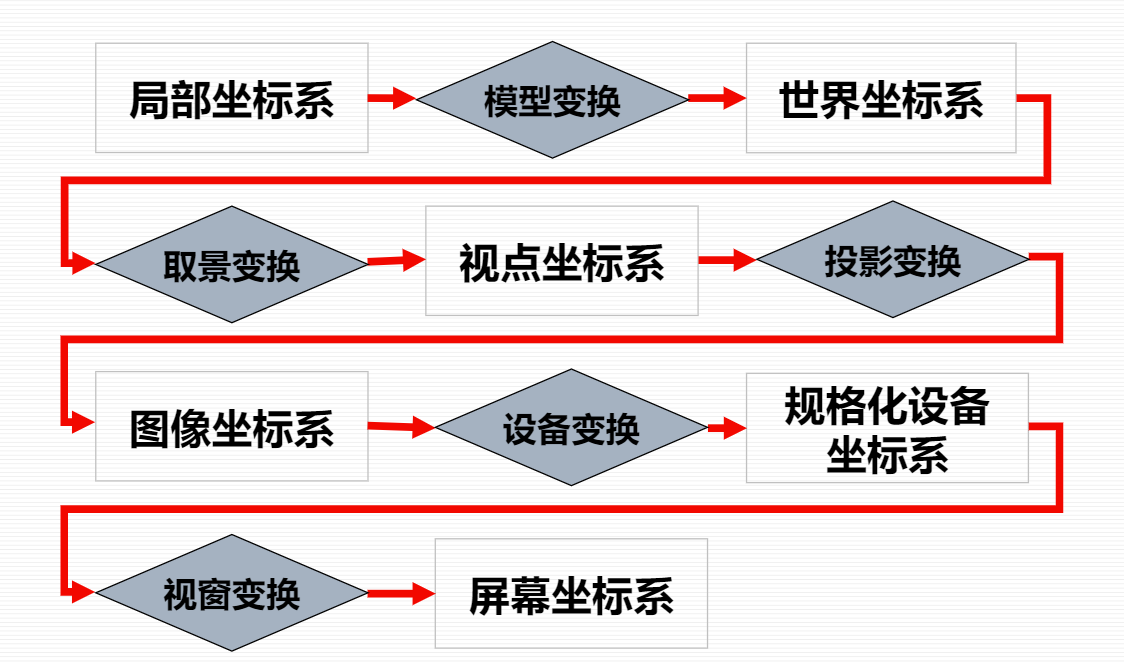

### 4.投影变换

#### 平行投影

略

#### 透视投影

- 灭点:3D物体的一组平行线投影后收敛于一点,称为灭点.
- 主灭点:3D物体**平行于坐标轴的平行线**收敛产生的灭点.
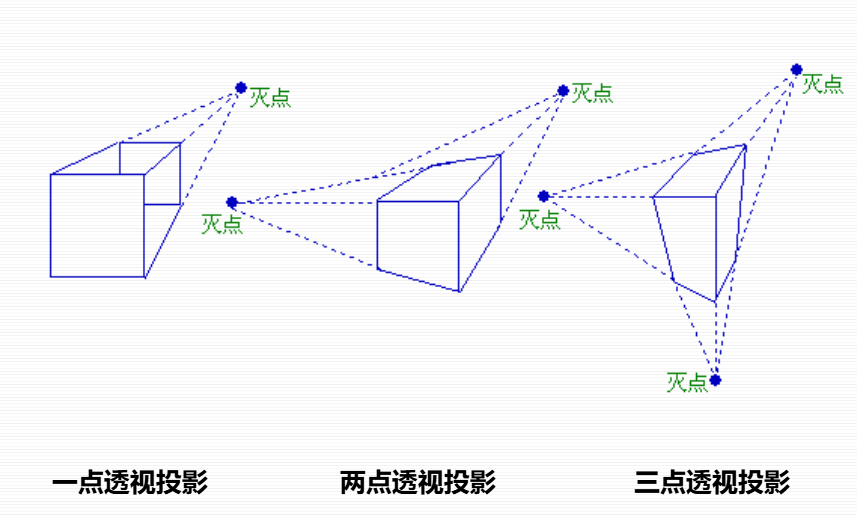

#### 一点,二点,三点透视

##### 一点透视

对变换:
$$ 
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0 \\
p & q & r & 1\\
\end{bmatrix}
\cdot 
\begin{bmatrix}x\\y\\z\\1\end{bmatrix}$$

令$p=r=0$,得到坐标$\begin{bmatrix}x\\y\\z\\qy+1\end{bmatrix}$.

齐次化后,当$y \to \infty$,有坐标$\begin{bmatrix}0\\\frac{1}{q}\\0\\1\end{bmatrix}$.所有点经过变换后均集中于Y轴上一点.称这一点为灭点$\begin{bmatrix}0\\\frac{1}{q}\\0\end{bmatrix}$.

同理,p,q,r分别不为零都有这个结果.

## 第六章:裁剪

### 1.裁剪操作在渲染pipeline中的位置

### 2.直线裁剪算法

#### Cohen-Sutherland裁剪算法

基本思想:对于每条待裁剪的线段$P_1P_2$,分三种情况:

- 若完全在窗口内,显示;
- 若完全在窗口外,丢弃;
- 否则:
  - 求线段与窗口边界的交点,在交点处把线段分为两段.
  - 其中一段在窗口外,丢弃,之后对另一端重复.

编码规则:

$$
\begin{align}
C_t(top) = \begin{cases}
1 & ,if y > y_{max}; \\
0 & ,otherwise.\\
\end{cases}
C_b(bottom) = \begin{cases}
1 & ,if y < y_{min}; \\
0 & ,otherwise.\\
\end{cases}\\
C_r(right) = \begin{cases}
1 & ,if x > x_{max}; \\
0 & ,otherwise.\\
\end{cases}
C_l(left) = \begin{cases}
1 & ,if x > x_{min}; \\
0 & ,otherwise.\\
\end{cases}
\end{align}
$$

对直线段的两端点,编码后:
- 若两端点编码全为0,则该直线段在窗口内,该直线段直接保留.
- 进行逻辑与运算:
  - 结果非0,说明该直线段在窗口外,直接舍弃.
  - 结果为0,需要求该直线和窗口边界的交点.
- 若需要求交:
  - 将两个端点进行逻辑或运算,根据1的位置来确定可能相交的窗口边.
  - 求交按照固定的顺序来,左右下上或上下右左.一条线段与窗口最多求交四次.
 
例如:

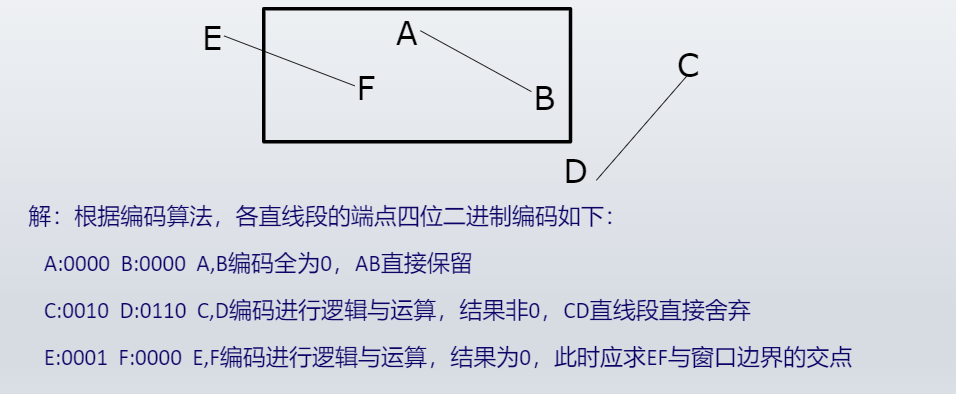


